In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

In [26]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
ds = [1] #[2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 500  # number of trials

In [10]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([np.ones(n_pos + n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

In [13]:
# choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1

n_val_pos = 200
n_val_neg = 200

mu_pos_scalar = 0.5 # class 1 mean
mu_neg_scalar = -0.5 # class -1 mean

sigma_neg = 1
sigmas = np.linspace(1.5, 0.1, 31) # different sigmas to run the experiments on

In [12]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_2(t):
    dfs = []
    for d in ds:
        mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
        mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))
        for sigma in sigmas:
            seed = hash((t, d, sigma)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v =  generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma, sigma_neg, rng, d)
            x_val, y_val, _ =  generate_gaus_data(n_val_pos, n_val_neg, mu_pos, mu_neg, sigma, sigma_neg, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['sigma_pos'] = sigma
            df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [ ]:
is_throw = True
mega_df_T = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
is_throw = False
mega_df_F = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

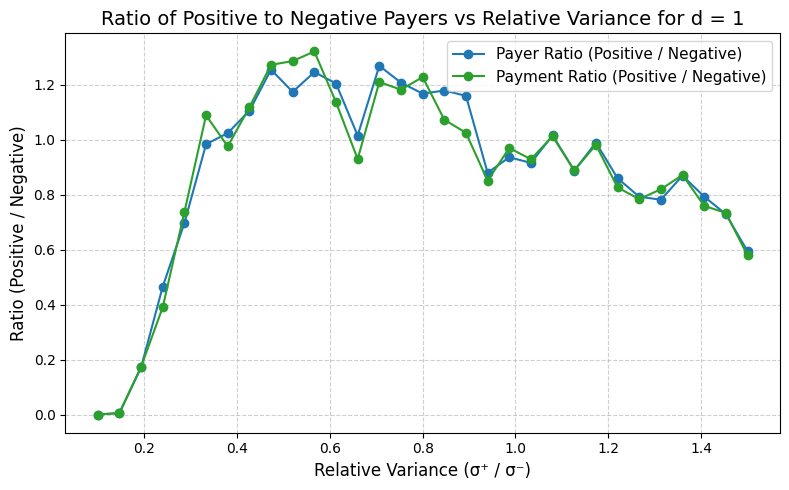

In [52]:
sigma_ratio(mega_df_mu_F, T, var = 'sigma_pos', ds = [1])

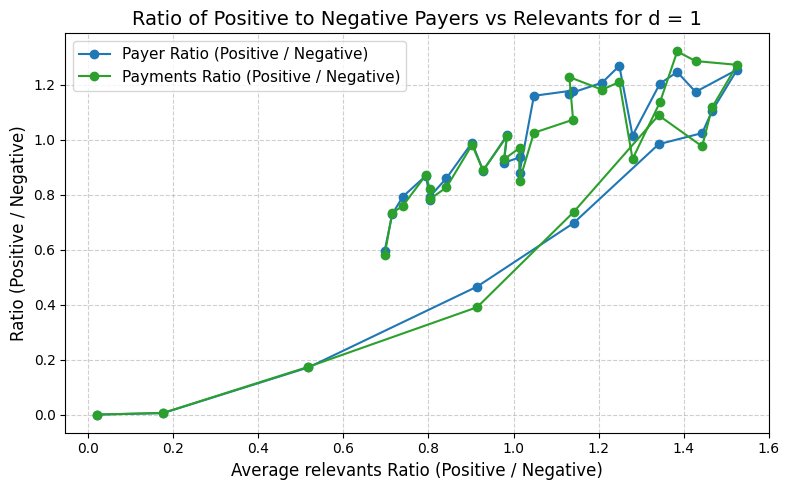

In [56]:
relevant_ratio(mega_df_mu_F, T, var = 'sigma_pos', ds = [1])

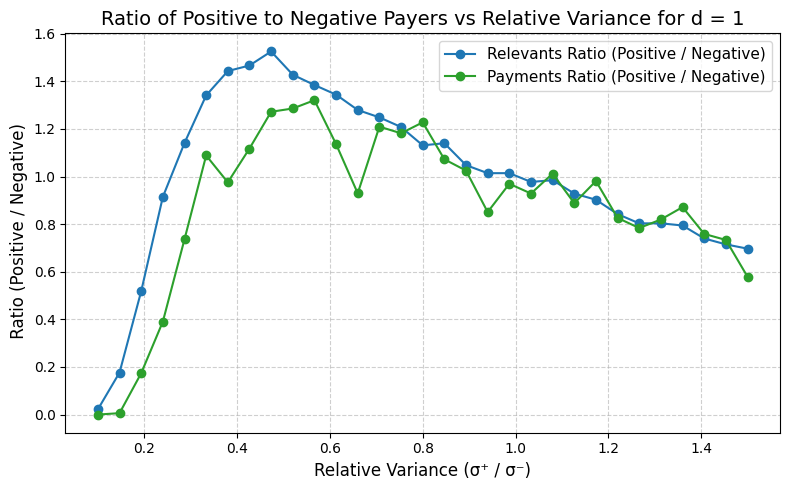

In [55]:
sigma_ratio_relevants(mega_df_mu_F, T, var = 'sigma_pos', ds = [1])

In [30]:
cols = ["agent", "true_v", "is_relevant", "support", "t", "d", "sigma_pos", "label"]

merged_df = pd.merge(
    mega_df_mu_T,
    mega_df_mu_F,
    on=cols,
    how="inner",
    suffixes=("_T", "_F")
)


In [31]:
abs(merged_df['critical_v_T'] - merged_df['critical_v_F']).max() 

np.float64(0.497005358860406)